In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.feature_engineering import load_data, feature_engineering

# Load your data
data = load_data('../data/raw/dataset_with_descriptions_cleaned.csv')

# --- Always ensure all categories are present before feature engineering ---
import pandas as pd
all_categories = ['Hotel', 'Restaurant', 'Tourist Attraction', 'Transportation']

# Debugging: Check if 'category_name' exists in the dataset
print("Columns in the dataset:", data.columns.tolist())
if 'category_name' in data.columns:
    print("Unique values in 'category_name':", data['category_name'].unique())
    missing_categories = set(all_categories) - set(data['category_name'].dropna().unique())
    if missing_categories:
        print("Missing categories in the dataset:", missing_categories)
    data['category_name'] = pd.Categorical(data['category_name'], categories=all_categories)
    data = pd.get_dummies(data, columns=['category_name'], prefix='category_name')
    # Rearrange columns if you want a specific order
    category_cols = [f'category_name_{cat}' for cat in all_categories]
    other_cols = [col for col in data.columns if col not in category_cols]
    data = data[other_cols + category_cols]
    print("Final columns after one-hot encoding:", data.columns.tolist())
else:
    print("Column 'category_name' does not exist. Check your data loading and processing steps.")
    print("First few rows of the dataset:")
    print(data.head())

# Apply feature engineering (skip one-hot encoding for 'category_name')
def safe_feature_engineering(data):
    try:
        if any(col.startswith('category_name_') for col in data.columns):
            print("Skipping one-hot encoding for 'category_name' as it is already processed.")
        else:
            data = feature_engineering(data)
        print("Feature engineering completed successfully.")
        return data
    except Exception as e:
        print("Error during feature engineering:", str(e))
        print("Dataset at the time of error:")
        print(data.head())
        raise

engineered_data = safe_feature_engineering(data)

# Ensure 'average_rating' column exists
if 'average_rating' not in engineered_data.columns:
    print("Creating 'average_rating' column as it is missing.")
    engineered_data['average_rating'] = engineered_data['ratings'] / engineered_data['reviews_count']
    engineered_data['average_rating'] = engineered_data['average_rating'].fillna(0)  # Handle division by zero

# Now you can use 'engineered_data' for training models, etc.
print("First few rows of engineered data:")
print(engineered_data.head())

# Re-train models after ensuring all categories are included
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode province
le_province = LabelEncoder()
engineered_data['province_encoded'] = le_province.fit_transform(engineered_data['province_name'])

# Example: Use only one category per row (if possible)
# If only one-hot, you can use the columns directly or create a single label
category_cols = [col for col in engineered_data.columns if col.startswith('category_name_')]
engineered_data['category_encoded'] = engineered_data[category_cols].idxmax(axis=1).apply(lambda x: x.replace('category_name_', ''))

le_category = LabelEncoder()
engineered_data['category_encoded'] = le_category.fit_transform(engineered_data['category_encoded'])

# Select features
features = ['province_encoded', 'category_encoded', 'ratings', 'reviews_count', 'average_rating']
X = engineered_data[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train the models again
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# KNN
knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_scaled)

# KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
engineered_data['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=5)
engineered_data['agglo_cluster'] = agglo.fit_predict(X_scaled)

# Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=5, random_state=42)
engineered_data['gmm_cluster'] = gmm.fit_predict(X_scaled)

# Display results
print("KNN - Similar Places:")
distances, indices = knn.kneighbors([X_scaled[0]])
print(engineered_data.iloc[indices[0]][['name', 'province_name', 'ratings']])

print("\nCluster Assignments:")
print(engineered_data[['name', 'province_name', 'kmeans_cluster', 'agglo_cluster', 'gmm_cluster']].head(10))

Columns in the dataset: ['placeID', 'name', 'google_maps_link', 'images_url', 'province_id', 'province_name', 'latitude', 'longitude', 'category_id', 'category_name', 'ratings', 'reviews_count', 'description']
Unique values in 'category_name': ['Tourist Attraction' 'Hotel' 'Restaurant' 'Transportation']
Final columns after one-hot encoding: ['placeID', 'name', 'google_maps_link', 'images_url', 'province_id', 'province_name', 'latitude', 'longitude', 'category_id', 'ratings', 'reviews_count', 'description', 'category_name_Hotel', 'category_name_Restaurant', 'category_name_Tourist Attraction', 'category_name_Transportation']
Skipping one-hot encoding for 'category_name' as it is already processed.
Feature engineering completed successfully.
Creating 'average_rating' column as it is missing.
First few rows of engineered data:
                       placeID                         name  \
0  ChIJ42tqxz1RCTER36bOGZOA8fg     Royal Palace of Cambodia   
1  ChIJw8jeJSJRCTERp9gvbl8l0hM   Tuol S

## Data Preparation & Cleaning

In [2]:
# Check for missing values
print(engineered_data.isnull().sum())

# Fill or drop missing values as needed
engineered_data = engineered_data.fillna(0)  # or use dropna() if appropriate

# Check data types
print(engineered_data.dtypes)

# Remove duplicates if any
engineered_data = engineered_data.drop_duplicates()

placeID                             0
name                                0
google_maps_link                    0
images_url                          0
province_id                         0
province_name                       0
latitude                            0
longitude                           0
category_id                         0
ratings                             0
reviews_count                       0
description                         0
category_name_Hotel                 0
category_name_Restaurant            0
category_name_Tourist Attraction    0
category_name_Transportation        0
average_rating                      0
province_encoded                    0
category_encoded                    0
kmeans_cluster                      0
agglo_cluster                       0
gmm_cluster                         0
dtype: int64
placeID                              object
name                                 object
google_maps_link                     object
images_url         

In [3]:
# Fill missing values in 'average_rating' with the mean of the column
engineered_data['average_rating'] = engineered_data['average_rating'].fillna(engineered_data['average_rating'].mean())

# Double-check if all missing values are handled
print(engineered_data.isnull().sum())

placeID                             0
name                                0
google_maps_link                    0
images_url                          0
province_id                         0
province_name                       0
latitude                            0
longitude                           0
category_id                         0
ratings                             0
reviews_count                       0
description                         0
category_name_Hotel                 0
category_name_Restaurant            0
category_name_Tourist Attraction    0
category_name_Transportation        0
average_rating                      0
province_encoded                    0
category_encoded                    0
kmeans_cluster                      0
agglo_cluster                       0
gmm_cluster                         0
dtype: int64


In [4]:
# Check for any remaining missing values in the DataFrame
print(engineered_data.isnull().sum())

# Or, to quickly check if there are any missing values at all:
print("Any missing values?", engineered_data.isnull().values.any())

placeID                             0
name                                0
google_maps_link                    0
images_url                          0
province_id                         0
province_name                       0
latitude                            0
longitude                           0
category_id                         0
ratings                             0
reviews_count                       0
description                         0
category_name_Hotel                 0
category_name_Restaurant            0
category_name_Tourist Attraction    0
category_name_Transportation        0
average_rating                      0
province_encoded                    0
category_encoded                    0
kmeans_cluster                      0
agglo_cluster                       0
gmm_cluster                         0
dtype: int64
Any missing values? False


## Exploratory Data Analysis (EDA)

### Distribution of Ratings

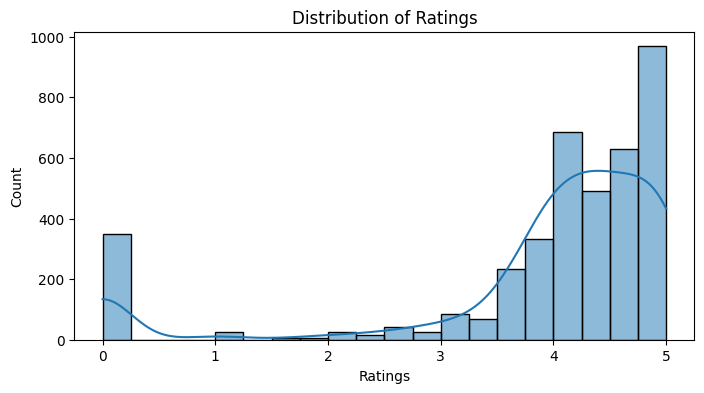

In [5]:
# Distribution of ratings
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(engineered_data['ratings'], bins=20, kde=True)
plt.title('Distribution of Ratings')
plt.xlabel('Ratings')
plt.ylabel('Count')
plt.show()

In [6]:
# Only run this BEFORE you do pd.get_dummies on 'category_name'
all_categories = ['Hotel', 'Restaurant', 'Tourist Attraction', 'Transportation']

# Check if 'category_name' exists
if 'category_name' in engineered_data.columns:
    engineered_data['category_name'] = pd.Categorical(engineered_data['category_name'], categories=all_categories)
    engineered_data = pd.get_dummies(engineered_data, columns=['category_name'], prefix='category_name')
    # Rearrange columns if you want a specific order
    category_cols = [f'category_name_{cat}' for cat in all_categories]
    other_cols = [col for col in engineered_data.columns if col not in category_cols]
    engineered_data = engineered_data[other_cols + category_cols]
else:
    print("Column 'category_name' does not exist. Check your data loading and processing steps.")

Column 'category_name' does not exist. Check your data loading and processing steps.


### Top Provinces by Number of Places

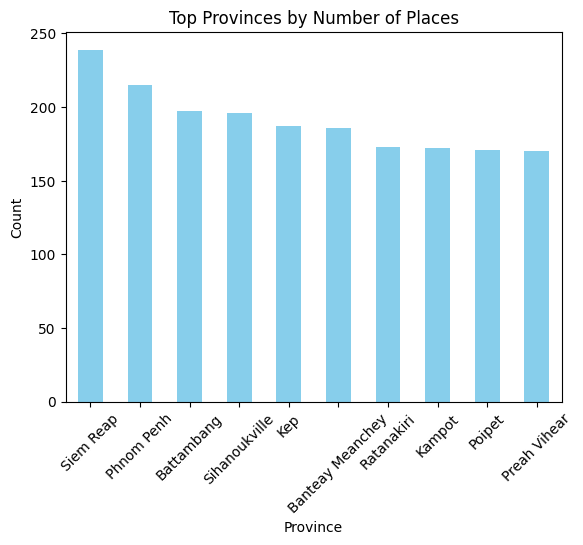

In [7]:
# Top provinces by number of places
top_provinces = engineered_data['province_name'].value_counts().head(10)
top_provinces.plot(kind='bar', color='skyblue')
plt.title('Top Provinces by Number of Places')
plt.ylabel('Count')
plt.xlabel('Province')
plt.xticks(rotation=45)
plt.show()

### Distribution of Reviews Count


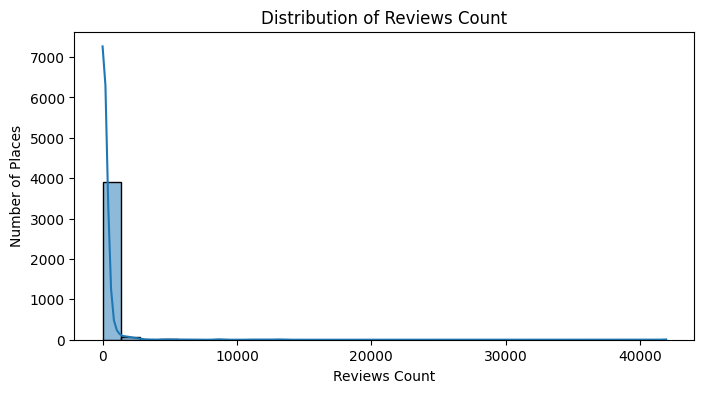

In [8]:
# Distribution of reviews count
plt.figure(figsize=(8,4))
sns.histplot(engineered_data['reviews_count'], bins=30, kde=True)
plt.title('Distribution of Reviews Count')
plt.xlabel('Reviews Count')
plt.ylabel('Number of Places')
plt.show()

### Average Rating by Province (Top 10)

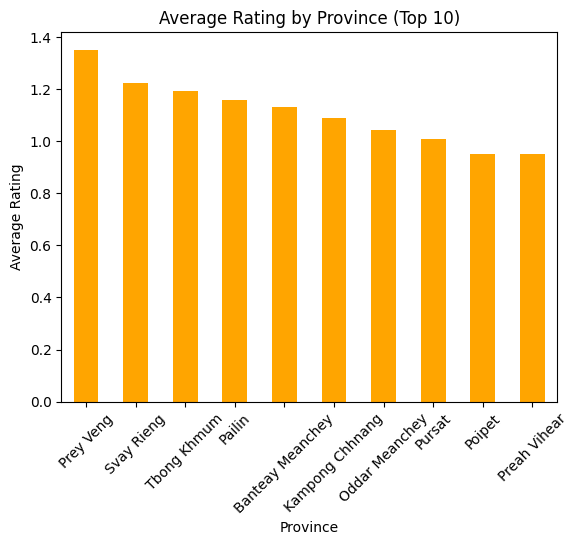

In [9]:
# Average rating by province (top 10 provinces)
avg_rating_province = engineered_data.groupby('province_name')['average_rating'].mean().sort_values(ascending=False).head(10)
avg_rating_province.plot(kind='bar', color='orange')
plt.title('Average Rating by Province (Top 10)')
plt.ylabel('Average Rating')
plt.xlabel('Province')
plt.xticks(rotation=45)
plt.show()

### Scatter Plot: Ratings vs. Reviews Count


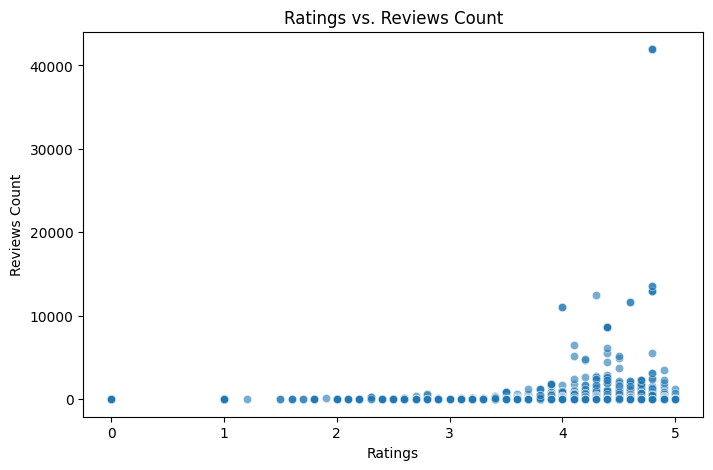

In [10]:
# Scatter plot: ratings vs. reviews count
plt.figure(figsize=(8,5))
sns.scatterplot(data=engineered_data, x='ratings', y='reviews_count', alpha=0.6)
plt.title('Ratings vs. Reviews Count')
plt.xlabel('Ratings')
plt.ylabel('Reviews Count')
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode province
le_province = LabelEncoder()
engineered_data['province_encoded'] = le_province.fit_transform(engineered_data['province_name'])

# Example: Use only one category per row (if possible)
# If only one-hot, you can use the columns directly or create a single label
category_cols = [col for col in engineered_data.columns if col.startswith('category_name_')]
engineered_data['category_encoded'] = engineered_data[category_cols].idxmax(axis=1).apply(lambda x: x.replace('category_name_', ''))

le_category = LabelEncoder()
engineered_data['category_encoded'] = le_category.fit_transform(engineered_data['category_encoded'])

# Select features
features = ['province_encoded', 'category_encoded', 'ratings', 'reviews_count', 'average_rating']
X = engineered_data[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Train 5 Different Models

### 1. K-Nearest Neighbors (KNN) – Find Similar Places

In [12]:
from sklearn.neighbors import NearestNeighbors

# Train the model
knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_scaled)

# Find 5 places similar to the first place in your dataset
distances, indices = knn.kneighbors([X_scaled[0]])
# Show the results
print(engineered_data.iloc[indices[0]][['name', 'province_name', 'ratings']])

                            name province_name  ratings
0       Royal Palace of Cambodia    Phnom Penh      4.3
2867             Ta Prohm Temple  Preah Vihear      4.8
1     Tuol Sleng Genocide Museum    Phnom Penh      4.6
3017  Tuol Sleng Genocide Museum     Prey Veng      4.6
215              Ta Prohm Temple     Siem Reap      4.8


### 2.. K-Means Clustering – Group Places into Clusters

In [13]:
from sklearn.cluster import KMeans

# Train the model
kmeans = KMeans(n_clusters=5, random_state=42)
engineered_data['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

# See which cluster each place belongs to
print(engineered_data[['name', 'province_name', 'kmeans_cluster']].head())

                          name province_name  kmeans_cluster
0     Royal Palace of Cambodia    Phnom Penh               0
1   Tuol Sleng Genocide Museum    Phnom Penh               0
2          Wat Phnom Daun Penh    Phnom Penh               0
3  National Museum of Cambodia    Phnom Penh               0
4        Independence Monument    Phnom Penh               0


### 3.Agglomerative Clustering – Hierarchical Grouping

In [14]:
from sklearn.cluster import AgglomerativeClustering

# Train the model
agglo = AgglomerativeClustering(n_clusters=5)
engineered_data['agglo_cluster'] = agglo.fit_predict(X_scaled)

# See cluster assignments
print(engineered_data[['name', 'province_name', 'agglo_cluster']].head())

                          name province_name  agglo_cluster
0     Royal Palace of Cambodia    Phnom Penh              1
1   Tuol Sleng Genocide Museum    Phnom Penh              1
2          Wat Phnom Daun Penh    Phnom Penh              1
3  National Museum of Cambodia    Phnom Penh              1
4        Independence Monument    Phnom Penh              1


### 4.Gaussian Mixture Model (GMM) – Soft Clustering

In [15]:
from sklearn.mixture import GaussianMixture

# Train the model
gmm = GaussianMixture(n_components=5, random_state=42)
engineered_data['gmm_cluster'] = gmm.fit_predict(X_scaled)

# See cluster assignments
print(engineered_data[['name', 'province_name', 'gmm_cluster']].head())

                          name province_name  gmm_cluster
0     Royal Palace of Cambodia    Phnom Penh            0
1   Tuol Sleng Genocide Museum    Phnom Penh            0
2          Wat Phnom Daun Penh    Phnom Penh            0
3  National Museum of Cambodia    Phnom Penh            0
4        Independence Monument    Phnom Penh            0


### 5.PCA + KNN – Visualize and Find Similar Places


In [16]:
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Train KNN on PCA-reduced data
knn_pca = NearestNeighbors(n_neighbors=5)
knn_pca.fit(X_pca)

# Find similar places in PCA space
distances, indices = knn_pca.kneighbors([X_pca[0]])
print(engineered_data.iloc[indices[0]][['name', 'province_name', 'ratings']])

                          name     province_name  ratings
0     Royal Palace of Cambodia        Phnom Penh      4.3
1573     MEILI WAN HE Hotel ll  Banteay Meanchey      1.0
2101   Phnom Penh Night Market            Kandal      4.0
218               Bayon Temple         Siem Reap      4.8
215            Ta Prohm Temple         Siem Reap      4.8


In [17]:
# For KNN
distances, indices = knn.kneighbors([X_scaled[0]])
print("KNN - Similar Places:")
print(engineered_data.iloc[indices[0]][['name', 'province_name', 'ratings']])

# For PCA+KNN
distances, indices = knn_pca.kneighbors([X_pca[0]])
print("PCA+KNN - Similar Places:")
print(engineered_data.iloc[indices[0]][['name', 'province_name', 'ratings']])

KNN - Similar Places:
                            name province_name  ratings
0       Royal Palace of Cambodia    Phnom Penh      4.3
2867             Ta Prohm Temple  Preah Vihear      4.8
1     Tuol Sleng Genocide Museum    Phnom Penh      4.6
3017  Tuol Sleng Genocide Museum     Prey Veng      4.6
215              Ta Prohm Temple     Siem Reap      4.8
PCA+KNN - Similar Places:
                          name     province_name  ratings
0     Royal Palace of Cambodia        Phnom Penh      4.3
1573     MEILI WAN HE Hotel ll  Banteay Meanchey      1.0
2101   Phnom Penh Night Market            Kandal      4.0
218               Bayon Temple         Siem Reap      4.8
215            Ta Prohm Temple         Siem Reap      4.8


In [18]:
# Show first 10 places with their cluster assignments
print(engineered_data[['name', 'province_name', 'kmeans_cluster', 'agglo_cluster', 'gmm_cluster']].head(10))

                                                name province_name  \
0                           Royal Palace of Cambodia    Phnom Penh   
1                         Tuol Sleng Genocide Museum    Phnom Penh   
2                                Wat Phnom Daun Penh    Phnom Penh   
3                        National Museum of Cambodia    Phnom Penh   
4                              Independence Monument    Phnom Penh   
5                        Choeung Ek Genocidal Center    Phnom Penh   
6                                      Silver Pagoda    Phnom Penh   
7                                  Royal Palace Park    Phnom Penh   
8                            Sisowath Riverside Park    Phnom Penh   
9  Statue of His Majesty Preah Bat Samdech Preah ...    Phnom Penh   

   kmeans_cluster  agglo_cluster  gmm_cluster  
0               0              1            0  
1               0              1            0  
2               0              1            0  
3               0              1     

In [19]:
print(engineered_data['kmeans_cluster'].value_counts())
print(engineered_data['agglo_cluster'].value_counts())
print(engineered_data['gmm_cluster'].value_counts())

kmeans_cluster
1    2178
0     999
4     413
3     394
2       3
Name: count, dtype: int64
agglo_cluster
0    2253
1    1020
4     371
2     340
3       3
Name: count, dtype: int64
gmm_cluster
4    1547
1    1331
0     735
3     371
2       3
Name: count, dtype: int64


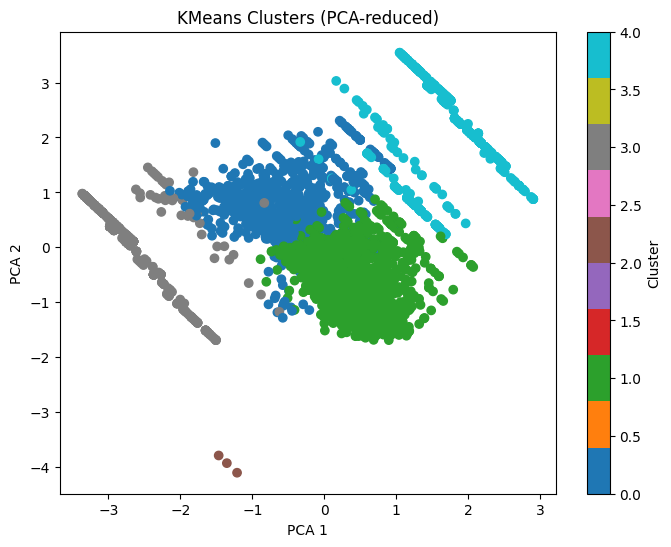

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=engineered_data['kmeans_cluster'], cmap='tab10')
plt.title('KMeans Clusters (PCA-reduced)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Cluster')
plt.show()

In [21]:
# See Cluster Balance
# Check how many places are in each cluster
print("KMeans cluster sizes:")
print(engineered_data['kmeans_cluster'].value_counts())
print("\nAgglomerative cluster sizes:")
print(engineered_data['agglo_cluster'].value_counts())
print("\nGMM cluster sizes:")
print(engineered_data['gmm_cluster'].value_counts())

KMeans cluster sizes:
kmeans_cluster
1    2178
0     999
4     413
3     394
2       3
Name: count, dtype: int64

Agglomerative cluster sizes:
agglo_cluster
0    2253
1    1020
4     371
2     340
3       3
Name: count, dtype: int64

GMM cluster sizes:
gmm_cluster
4    1547
1    1331
0     735
3     371
2       3
Name: count, dtype: int64


In [22]:
# Make Recommendations Based on User Answers (QCM)
# Example user answers
user_province = "Siem Reap"
user_category = "Tourist Attraction"
user_min_rating = 4.0

# Filter based on user answers
filtered = engineered_data.copy()
filtered = filtered[filtered['province_name'] == user_province]
filtered = filtered[filtered['ratings'] >= user_min_rating]
cat_col = f'category_name_{user_category}'
if cat_col in filtered.columns:
    filtered = filtered[filtered[cat_col] == 1]

# Show top 5 by reviews_count (popularity)
recommendations = filtered.sort_values(by='reviews_count', ascending=False).head(5)
print("Recommended places for you:")
print(recommendations[['name', 'province_name', 'ratings', 'reviews_count']])

Recommended places for you:
                            name province_name  ratings  reviews_count
219                   Angkor Wat     Siem Reap      4.8        41938.0
218                 Bayon Temple     Siem Reap      4.8        13512.0
215              Ta Prohm Temple     Siem Reap      4.8        13018.0
228                   Pub Street     Siem Reap      4.4         6171.0
255  Phare, The Cambodian Circus     Siem Reap      4.8         5597.0


In [23]:
# (Optional) Use KNN for Similar Places After Filtering
if not filtered.empty:
    idx = filtered.index[0]
    distances, indices = knn.kneighbors([X_scaled[idx]])
    print("Places similar to your top match:")
    print(engineered_data.iloc[indices[0]][['name', 'province_name', 'ratings']])
else:
    print("No places found for your criteria.")

Places similar to your top match:
                 name province_name  ratings
215   Ta Prohm Temple     Siem Reap      4.8
218      Bayon Temple     Siem Reap      4.8
2867  Ta Prohm Temple  Preah Vihear      4.8
3695  Ta Prohm Temple         Takeo      4.8
3700     Bayon Temple         Takeo      4.8


In [24]:
# User answers
user_province = "Siem Reap"
user_category = "Tourist Attraction"
user_min_rating = 4.0

# Filter
filtered = engineered_data.copy()
filtered = filtered[filtered['province_name'] == user_province]
filtered = filtered[filtered['ratings'] >= user_min_rating]
cat_col = f'category_name_{user_category}'
if cat_col in filtered.columns:
    filtered = filtered[filtered[cat_col] == 1]

# Recommend top 5 by popularity
recommendations = filtered.sort_values(by='reviews_count', ascending=False).head(5)
print("Recommended places for you:")
print(recommendations[['name', 'province_name', 'ratings', 'reviews_count']])

# (Optional) Find similar places to the top match
if not filtered.empty:
    idx = filtered.index[0]
    distances, indices = knn.kneighbors([X_scaled[idx]])
    print("Places similar to your top match:")
    print(engineered_data.iloc[indices[0]][['name', 'province_name', 'ratings']])
else:
    print("No places found for your criteria.")

Recommended places for you:
                            name province_name  ratings  reviews_count
219                   Angkor Wat     Siem Reap      4.8        41938.0
218                 Bayon Temple     Siem Reap      4.8        13512.0
215              Ta Prohm Temple     Siem Reap      4.8        13018.0
228                   Pub Street     Siem Reap      4.4         6171.0
255  Phare, The Cambodian Circus     Siem Reap      4.8         5597.0
Places similar to your top match:
                 name province_name  ratings
215   Ta Prohm Temple     Siem Reap      4.8
218      Bayon Temple     Siem Reap      4.8
2867  Ta Prohm Temple  Preah Vihear      4.8
3695  Ta Prohm Temple         Takeo      4.8
3700     Bayon Temple         Takeo      4.8


###  Filter DataFrame Based on QCM

In [25]:
# Define user_answers dictionary with example answers
user_answers = {
    "province": "Siem Reap",
    "category": "Tourist Attraction",
    "ratings": "Yes",           # "Yes" means user wants high ratings
    "entry_free": "Yes",        # Only if you have 'entry_free' column
    "popularity": "Very important"
}

# Now run your filtering code
filtered = engineered_data.copy()

# Province filter
if "province" in user_answers:
    filtered = filtered[filtered['province_name'] == user_answers["province"]]

# Category filter
if "category" in user_answers:
    cat_col = f'category_name_{user_answers["category"]}'
    if cat_col in filtered.columns:
        filtered = filtered[filtered[cat_col] == 1]

# Ratings filter
if user_answers.get("ratings") == "Yes":
    filtered = filtered[filtered['ratings'] >= 4.0]  # or your threshold

# Entry free filter (if you have a column like 'entry_free')
if "entry_free" in user_answers and "entry_free" in filtered.columns:
    if user_answers["entry_free"] == "Yes":
        filtered = filtered[filtered['entry_free'] == 1]

# Popularity sorting
if user_answers.get("popularity") == "Very important":
    filtered = filtered.sort_values(by='reviews_count', ascending=False)
elif user_answers.get("popularity") == "Somewhat important":
    filtered = filtered.sort_values(by='reviews_count', ascending=False)

# Show top 5 recommendations
recommendations = filtered.head(5)
print("Recommended places for you:")
print(recommendations[['name', 'province_name', 'ratings', 'reviews_count']])

Recommended places for you:
                            name province_name  ratings  reviews_count
219                   Angkor Wat     Siem Reap      4.8        41938.0
218                 Bayon Temple     Siem Reap      4.8        13512.0
215              Ta Prohm Temple     Siem Reap      4.8        13018.0
228                   Pub Street     Siem Reap      4.4         6171.0
255  Phare, The Cambodian Circus     Siem Reap      4.8         5597.0


In [26]:
category_cols = [col for col in engineered_data.columns if col.startswith('category_name_')]

In [27]:
print([col for col in engineered_data.columns if col.startswith('category_name_')])

['category_name_Hotel', 'category_name_Restaurant', 'category_name_Tourist Attraction', 'category_name_Transportation']
